In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, UpSampling2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam

In [22]:
# === Load CIFAR-10 ===
(x_train, _), _ = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0



In [27]:
# === Normal Autoencoder ===
def build_autoencoder():
    input_img = Input(shape=(32, 32, 3))

    # Encoder
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)  # 16x16x32
    x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)  # 8x8x16

    # Decoder
    x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2, 2))(x)  # 16x16x16
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)  # 32x32x32
    decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)  # 32x32x3

    autoencoder = Model(input_img, decoded)
    encoder = Model(input_img, encoded)

    # Decoder model (reuses decoder part only)
    encoded_input = Input(shape=(8, 8, 16))
    d = autoencoder.layers[-5](encoded_input)
    d = autoencoder.layers[-4](d)
    d = autoencoder.layers[-3](d)
    d = autoencoder.layers[-2](d)
    d = autoencoder.layers[-1](d)
    decoder = Model(encoded_input, d)

    return autoencoder, encoder, decoder

autoencoder, encoder, decoder = build_autoencoder()
autoencoder.compile(optimizer=Adam(), loss='mse')
autoencoder.fit(x_train, x_train, epochs=20, batch_size=256, shuffle=True)

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0312
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0096
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0078
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0070
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0065
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0062
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0059
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0056
Epoch 9/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0055
Epoch 10/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0053
Epoch 11/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0052
Epoch 12/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0050
Epoch 13/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0049
Epoch 14/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0048
Epoch 15/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s

In [28]:
# === Denoising Autoencoder ===
# Add noise
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)

denoise_autoencoder, _, denoise_decoder = build_autoencoder()
denoise_autoencoder.compile(optimizer=Adam(), loss='mse')
denoise_autoencoder.fit(x_train_noisy, x_train, epochs=20, batch_size=256, shuffle=True)




Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0307
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0112
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0094
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0087
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0082
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0079
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0077
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0075
Epoch 9/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0073
Epoch 10/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0072
Epoch 11/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0071
Epoch 12/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0069
Epoch 13/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0068
Epoch 14/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0068
Epoch 15/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s

In [29]:
# === Generate 5 Random Latent Vectors ===
noise_vectors = np.random.normal(loc=5.0, scale=1.0, size=(5, 8, 8, 16))



In [33]:
# === Generate images from both decoders ===
generated_from_normal = decoder.predict(noise_vectors)
generated_from_denoise = denoise_decoder.predict(noise_vectors)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


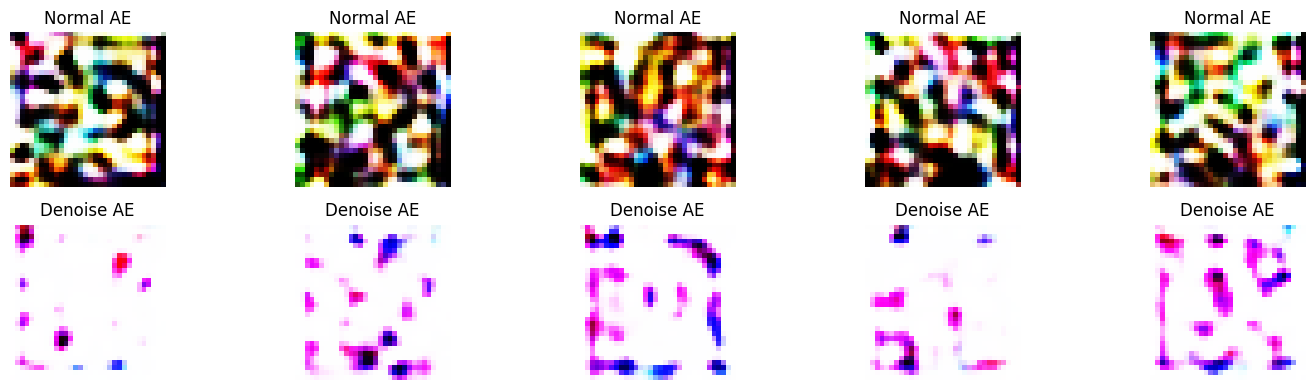

In [34]:
# === Display the Results ===
plt.figure(figsize=(15, 4))
for i in range(5):
    # Normal AE
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(generated_from_normal[i])
    plt.title("Normal AE")
    plt.axis("off")

    # Denoising AE
    ax = plt.subplot(2, 5, i + 6)
    plt.imshow(generated_from_denoise[i])
    plt.title("Denoise AE")
    plt.axis("off")

plt.tight_layout()
plt.show()